In [0]:
from pyspark.sql import functions as F
from pyspark.sql.window import Window
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

In [0]:
dbutils.fs.put("dbfs:/tmp/skyjet/raw/flights.csv", """flight_id,airline,from_city,to_city,duration,status
F101,Indigo,Hyderabad,Delhi,140,On Time
F102,Air India,Mumbai,Chennai,120,Delayed
F103,Vistara,Bangalore,Hyderabad,90,On Time
F104,Indigo,Delhi,Mumbai,130,Cancelled
F105,Air India,Chennai,Bangalore,80,On Time
F106,Akasa,Pune,Delhi,150,Delayed
F107,Vistara,Hyderabad,Kolkata,160,On Time
F108,Indigo,Mumbai,Hyderabad,110,On Time
F109,Akasa,Delhi,Chennai,145,Delayed
F110,Air India,Bangalore,Mumbai,95,On Time
F111,Indigo,Hyderabad,Goa,75,On Time
F112,Vistara,Goa,Delhi,150,Cancelled
F113,Akasa,Chennai,Pune,100,On Time
F114,Air India,Kolkata,Bangalore,170,Delayed
F115,Indigo,Delhi,Hyderabad,135,On Time""", overwrite=True)

Wrote 653 bytes.


True

In [0]:
dbutils.fs.put("dbfs:/tmp/skyjet/raw/bookings.csv", """booking_id,flight_id,passenger_name,travel_class,ticket_price,booking_date
B1001,F101,Rahul Sharma,Economy,8500,2026-06-01
B1002,F101,Priya Reddy,Business,22000,2026-06-01
B1003,F102,Amit Kumar,Economy,9000,2026-06-02
B1004,F103,Sneha Patel,Premium Economy,15000,2026-06-02
B1005,F104,Farhan Ali,Economy,7500,2026-06-03
B1006,F105,Neha Singh,Business,25000,2026-06-03
B1007,F106,Arjun Verma,Economy,10000,2026-06-04
B1008,F107,Meera Nair,Premium Economy,17000,2026-06-04
B1009,F108,Kiran Rao,Economy,9500,2026-06-05
B1010,F109,Nisha Reddy,Business,28000,2026-06-05
B1011,F110,David Thomas,Economy,8000,2026-06-06
B1012,F111,Ayesha Khan,Premium Economy,16000,2026-06-06
B1013,F112,Rohit Sharma,Economy,7000,2026-06-07
B1014,F113,Pooja Mehta,Business,24000,2026-06-07
B1015,F114,Sanjay Gupta,Economy,10500,2026-06-08
B1016,F115,Divya Iyer,Premium Economy,18000,2026-06-08
B1017,F101,Vikram Singh,Economy,8500,2026-06-09
B1018,F103,Anjali Rao,Business,23000,2026-06-09
B1019,F107,Faiz Ahmed,Economy,9500,2026-06-10
B1020,F110,Megha Kapoor,Premium Economy,15500,2026-06-10""", overwrite=True)

Wrote 1068 bytes.


True

In [0]:
dbutils.fs.put("dbfs:/tmp/skyjet/raw/passenger_preferences.json", """[
  {"passenger_name": "Rahul Sharma", "meal": "Veg", "seat": "Window", "extra_baggage": true},
  {"passenger_name": "Priya Reddy", "meal": "Non-Veg", "seat": "Aisle", "extra_baggage": false},
  {"passenger_name": "Amit Kumar", "meal": "Veg", "seat": "Middle", "extra_baggage": false},
  {"passenger_name": "Sneha Patel", "meal": "Jain", "seat": "Window", "extra_baggage": true},
  {"passenger_name": "Farhan Ali", "meal": "Non-Veg", "seat": "Aisle", "extra_baggage": false},
  {"passenger_name": "Neha Singh", "meal": "Veg", "seat": "Window", "extra_baggage": true},
  {"passenger_name": "Arjun Verma", "meal": "Veg", "seat": "Middle", "extra_baggage": false},
  {"passenger_name": "Meera Nair", "meal": "Jain", "seat": "Window", "extra_baggage": true},
  {"passenger_name": "Kiran Rao", "meal": "Veg", "seat": "Aisle", "extra_baggage": false},
  {"passenger_name": "Nisha Reddy", "meal": "Non-Veg", "seat": "Window", "extra_baggage": true},
  {"passenger_name": "David Thomas", "meal": "Veg", "seat": "Middle", "extra_baggage": false},
  {"passenger_name": "Ayesha Khan", "meal": "Jain", "seat": "Window", "extra_baggage": true},
  {"passenger_name": "Rohit Sharma", "meal": "Veg", "seat": "Aisle", "extra_baggage": false},
  {"passenger_name": "Pooja Mehta", "meal": "Non-Veg", "seat": "Window", "extra_baggage": true},
  {"passenger_name": "Sanjay Gupta", "meal": "Veg", "seat": "Middle", "extra_baggage": false},
  {"passenger_name": "Divya Iyer", "meal": "Jain", "seat": "Window", "extra_baggage": true}
]""", overwrite=True)

Wrote 1511 bytes.


True

In [0]:
df_flights_raw = spark.read.option("header", "true").option("inferSchema", "true").csv("dbfs:/tmp/skyjet/raw/flights.csv")
print("--- Schema: notebook_1_ingest_flights ---")
df_flights_raw.printSchema()


--- Schema: notebook_1_ingest_flights ---
root
 |-- flight_id: string (nullable = true)
 |-- airline: string (nullable = true)
 |-- from_city: string (nullable = true)
 |-- to_city: string (nullable = true)
 |-- duration: integer (nullable = true)
 |-- status: string (nullable = true)



In [0]:
df_bookings_raw = spark.read.option("header", "true").option("inferSchema", "true").csv("dbfs:/tmp/skyjet/raw/bookings.csv")
print("--- Data Sample: notebook_2_ingest_bookings ---")
df_bookings_raw.show(5)

--- Data Sample: notebook_2_ingest_bookings ---
+----------+---------+--------------+---------------+------------+------------+
|booking_id|flight_id|passenger_name|   travel_class|ticket_price|booking_date|
+----------+---------+--------------+---------------+------------+------------+
|     B1001|     F101|  Rahul Sharma|        Economy|        8500|  2026-06-01|
|     B1002|     F101|   Priya Reddy|       Business|       22000|  2026-06-01|
|     B1003|     F102|    Amit Kumar|        Economy|        9000|  2026-06-02|
|     B1004|     F103|   Sneha Patel|Premium Economy|       15000|  2026-06-02|
|     B1005|     F104|    Farhan Ali|        Economy|        7500|  2026-06-03|
+----------+---------+--------------+---------------+------------+------------+
only showing top 5 rows


In [0]:
df_pref_raw = spark.read.option("multiline", "true").json("dbfs:/tmp/skyjet/raw/passenger_preferences.json")
# Flatten explicit nested parameters if arrays were found; data is clean flat root struct elements
df_pref_clean = df_pref_raw.select("passenger_name", "meal", "seat", "extra_baggage")
print("--- Schema: notebook_3_ingest_preferences ---")
df_pref_clean.printSchema()

--- Schema: notebook_3_ingest_preferences ---
root
 |-- passenger_name: string (nullable = true)
 |-- meal: string (nullable = true)
 |-- seat: string (nullable = true)
 |-- extra_baggage: boolean (nullable = true)



In [0]:
pdf_flights = df_flights_raw.toPandas()
pdf_bookings = df_bookings_raw.toPandas()

In [0]:
pdf_merged = pd.merge(pdf_bookings, pdf_flights, on="flight_id", how="inner")
pdf_merged["route"] = pdf_merged["from_city"] + " -> " + pdf_merged["to_city"]

sns.set_theme(style="darkgrid")

/home/spark-689d6c35-cd27-4bfe-b5b6-de/.ipykernel/1993/command-5649029017506942-917976199:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=airline_rev, x="airline", y="ticket_price", palette="Blues_r")


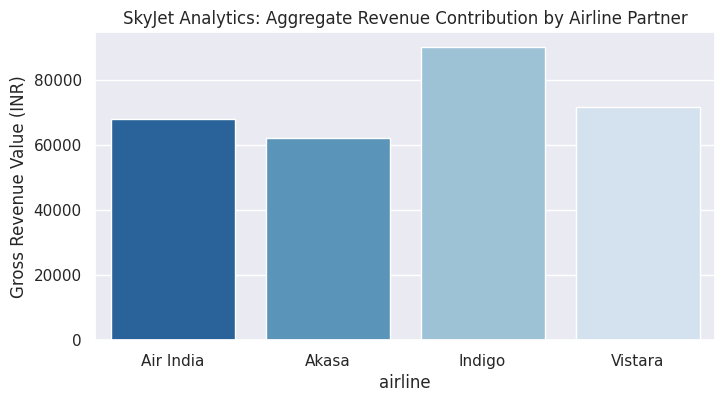

In [0]:
plt.figure(figsize=(8, 4))
airline_rev = pdf_merged.groupby("airline")["ticket_price"].sum().reset_index()
sns.barplot(data=airline_rev, x="airline", y="ticket_price", palette="Blues_r")
plt.title("SkyJet Analytics: Aggregate Revenue Contribution by Airline Partner")
plt.ylabel("Gross Revenue Value (INR)")
plt.show()

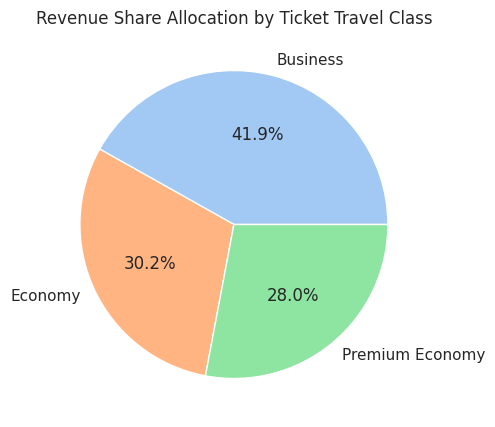

In [0]:
plt.figure(figsize=(5, 5))
class_rev = pdf_merged.groupby("travel_class")["ticket_price"].sum()
plt.pie(class_rev, labels=class_rev.index, autopct='%1.1f%%', colors=sns.color_palette("pastel"))
plt.title("Revenue Share Allocation by Ticket Travel Class")
plt.show()

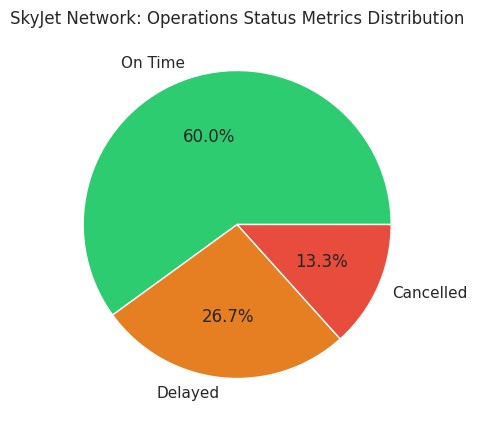

In [0]:
plt.figure(figsize=(5, 5))
status_counts = pdf_flights["status"].value_counts()
plt.pie(status_counts, labels=status_counts.index, autopct='%1.1f%%', colors=["#2ecc71", "#e67e22", "#e74c3c"])
plt.title("SkyJet Network: Operations Status Metrics Distribution")
plt.show()

/home/spark-689d6c35-cd27-4bfe-b5b6-de/.ipykernel/1993/command-5649029017506952-2713146269:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=route_rev, y="route", x="ticket_price", palette="viridis", orient="h")


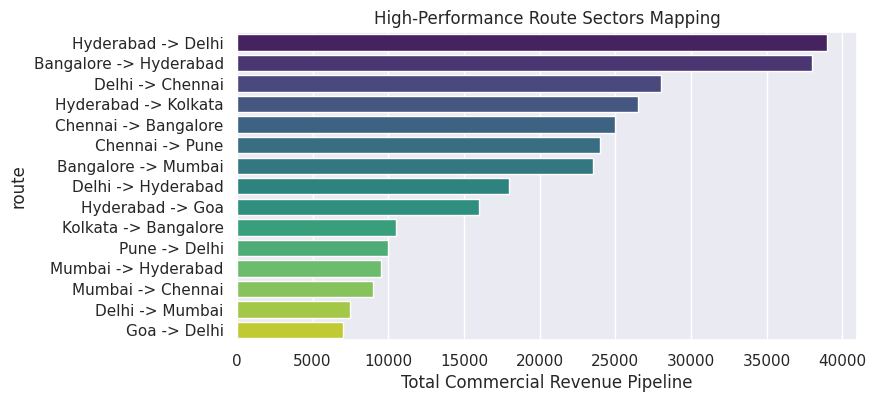

In [0]:
plt.figure(figsize=(8, 4))
route_rev = pdf_merged.groupby("route")["ticket_price"].sum().reset_index().sort_values(by="ticket_price", ascending=False)
sns.barplot(data=route_rev, y="route", x="ticket_price", palette="viridis", orient="h")
plt.title("High-Performance Route Sectors Mapping")
plt.xlabel("Total Commercial Revenue Pipeline")
plt.show()

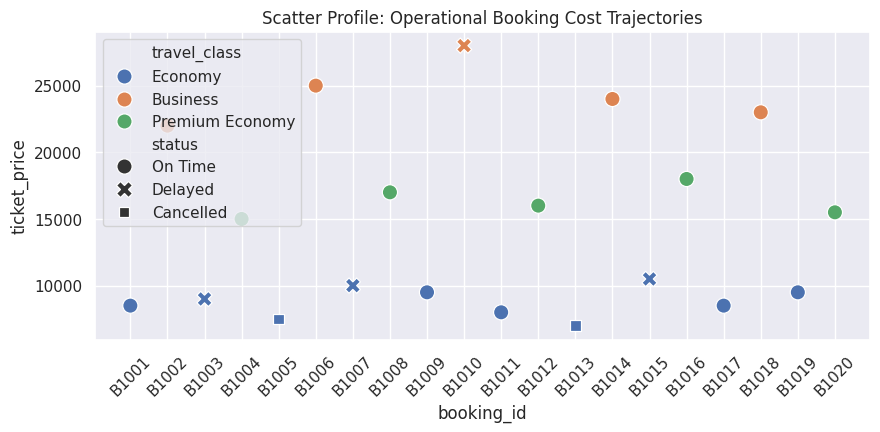

In [0]:
plt.figure(figsize=(10, 4))
sns.scatterplot(data=pdf_merged, x="booking_id", y="ticket_price", hue="travel_class", style="status", s=120)
plt.title("Scatter Profile: Operational Booking Cost Trajectories")
plt.xticks(rotation=45)
plt.show()

In [0]:
# Part 3 Transformations: Dynamic Business Bands Derived Fields
df_transformed_bookings = df_bookings_raw.withColumn(
    "price_band",
    F.when(F.col("ticket_price") > 20000, "Premium")
     .when(F.col("ticket_price") > 10000, "Standard")
     .otherwise("Budget")
)

df_transformed_flights = df_flights_raw.withColumn(
    "delay_flag",
    F.when(F.col("status") == "Delayed", "Yes").otherwise("No")
)

In [0]:
df_silver_journey = df_transformed_bookings \
    .join(df_transformed_flights, "flight_id", "inner") \
    .join(df_pref_clean, "passenger_name", "left")

print("--- Silver Consolidated Master Dataset Sample ---")
df_silver_journey.select("passenger_name", "flight_id", "price_band", "delay_flag", "meal", "seat").show(5)

--- Silver Consolidated Master Dataset Sample ---
+--------------+---------+----------+----------+-------+------+
|passenger_name|flight_id|price_band|delay_flag|   meal|  seat|
+--------------+---------+----------+----------+-------+------+
|  Rahul Sharma|     F101|    Budget|        No|    Veg|Window|
|   Priya Reddy|     F101|   Premium|        No|Non-Veg| Aisle|
|    Amit Kumar|     F102|    Budget|       Yes|    Veg|Middle|
|   Sneha Patel|     F103|  Standard|        No|   Jain|Window|
|    Farhan Ali|     F104|    Budget|        No|Non-Veg| Aisle|
+--------------+---------+----------+----------+-------+------+
only showing top 5 rows


In [0]:
df_silver_journey.createOrReplaceTempView("global_silver_journey")

# Part 5 Spark SQL Queries
print("--- SQL: Revenue by Route Mapping ---")
spark.sql("""
    SELECT from_city, to_city, SUM(ticket_price) as total_revenue, AVG(ticket_price) as avg_ticket_price
    FROM global_silver_journey 
    GROUP BY from_city, to_city 
    ORDER BY total_revenue DESC
""").show()

--- SQL: Revenue by Route Mapping ---
+---------+---------+-------------+----------------+
|from_city|  to_city|total_revenue|avg_ticket_price|
+---------+---------+-------------+----------------+
|Hyderabad|    Delhi|        39000|         13000.0|
|Bangalore|Hyderabad|        38000|         19000.0|
|    Delhi|  Chennai|        28000|         28000.0|
|Hyderabad|  Kolkata|        26500|         13250.0|
|  Chennai|Bangalore|        25000|         25000.0|
|  Chennai|     Pune|        24000|         24000.0|
|Bangalore|   Mumbai|        23500|         11750.0|
|    Delhi|Hyderabad|        18000|         18000.0|
|Hyderabad|      Goa|        16000|         16000.0|
|  Kolkata|Bangalore|        10500|         10500.0|
|     Pune|    Delhi|        10000|         10000.0|
|   Mumbai|Hyderabad|         9500|          9500.0|
|   Mumbai|  Chennai|         9000|          9000.0|
|    Delhi|   Mumbai|         7500|          7500.0|
|      Goa|    Delhi|         7000|          7000.0|
+-------

In [0]:
win_airline_rev = Window.partitionBy("airline").orderBy(F.desc("ticket_price"))
win_running_total = Window.orderBy("booking_date").rowsBetween(Window.unboundedPreceding, Window.currentRow)
win_dest_rank = Window.orderBy(F.desc("ticket_price"))

df_gold_metrics = df_silver_journey \
    .withColumn("flight_revenue_rank_within_airline", F.dense_rank().over(win_airline_rev)) \
    .withColumn("cumulative_network_running_revenue", F.sum("ticket_price").over(win_running_total)) \
    .withColumn("global_destination_dense_rank", F.dense_rank().over(Window.partitionBy("to_city").orderBy(F.desc("ticket_price"))))

print("--- Gold Analytics Window Output Preview ---")
df_gold_metrics.select("passenger_name", "airline", "to_city", "cumulative_network_running_revenue", "flight_revenue_rank_within_airline").show(5)

--- Gold Analytics Window Output Preview ---


/databricks/python/lib/python3.12/site-packages/pyspark/sql/connect/expressions.py:1160: UserWarning: WARN WindowExpression: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
  warnings.warn(


+--------------+---------+---------+----------------------------------+----------------------------------+
|passenger_name|  airline|  to_city|cumulative_network_running_revenue|flight_revenue_rank_within_airline|
+--------------+---------+---------+----------------------------------+----------------------------------+
|   Priya Reddy|   Indigo|    Delhi|                             22000|                                 1|
|  Rahul Sharma|   Indigo|    Delhi|                             30500|                                 5|
|    Amit Kumar|Air India|  Chennai|                             39500|                                 4|
|   Sneha Patel|  Vistara|Hyderabad|                             54500|                                 3|
|    Neha Singh|Air India|Bangalore|                             79500|                                 1|
+--------------+---------+---------+----------------------------------+----------------------------------+
only showing top 5 rows


In [0]:
delta_target_path = "dbfs:/tmp/delta/skyjet/booking_master_table"

In [0]:
dbutils.fs.rm(delta_target_path, recurse=True)
spark.sql("DROP TABLE IF EXISTS skyjet_managed_booking_master")
spark.sql("DROP TABLE IF EXISTS skyjet_external_booking_master")

DataFrame[]

In [0]:
df_silver_journey.write.format("delta").mode("overwrite").save(delta_target_path)

df_silver_journey.write.format("delta").mode("overwrite").saveAsTable("skyjet_managed_booking_master")



In [0]:
%sql
CREATE TABLE skyjet_external_booking_master
USING DELTA
LOCATION 'dbfs:/tmp/delta/skyjet/booking_master_table'

num_affected_rows,num_inserted_rows


In [0]:
print("Executing standard Delta Vacuum cleanups...")
spark.sql(f"VACUUM delta.`{delta_target_path}` RETAIN 168 HOURS")

Executing standard Delta Vacuum cleanups...


DataFrame[path: string]

In [0]:
# Load Target Delta Table directly into DeltaTable control object instance
target_delta_table = DeltaTable.forPath(spark, delta_target_path)

In [0]:
target_delta_table.alias("target").merge(
    source = df_incremental_day2.alias("source"),
    condition = "target.booking_id = source.booking_id"
).whenMatchedUpdate(set = {
    "flight_id": "source.flight_id",
    "passenger_name": "source.passenger_name",
    "travel_class": "source.travel_class",
    "ticket_price": "source.ticket_price",
    "booking_date": "source.booking_date"
}).whenNotMatchedInsert(values = {
    "booking_id": "source.booking_id",
    "flight_id": "source.flight_id",
    "passenger_name": "source.passenger_name",
    "travel_class": "source.travel_class",
    "ticket_price": "source.ticket_price",
    "booking_date": "source.booking_date"
}).execute()

DataFrame[num_affected_rows: bigint, num_updated_rows: bigint, num_deleted_rows: bigint, num_inserted_rows: bigint]

In [0]:
# Part 9: Time Travel Verification Queries
print("--- Time Travel: Historical Read (Version 0 - Initial Day 1 State) ---")
spark.read.format("delta").option("versionAsOf", 0).load(delta_target_path).filter("booking_id = 'B1002'").show()

print("--- Time Travel: Present Read (Latest Version - Post Day 2 Merge State) ---")
spark.read.format("delta").load(delta_target_path).filter("booking_id = 'B1002'").show()

--- Time Travel: Historical Read (Version 0 - Initial Day 1 State) ---
+--------------+---------+----------+------------+------------+------------+----------+-------+---------+-------+--------+-------+----------+-------+-----+-------------+
|passenger_name|flight_id|booking_id|travel_class|ticket_price|booking_date|price_band|airline|from_city|to_city|duration| status|delay_flag|   meal| seat|extra_baggage|
+--------------+---------+----------+------------+------------+------------+----------+-------+---------+-------+--------+-------+----------+-------+-----+-------------+
|   Priya Reddy|     F101|     B1002|    Business|       22000|  2026-06-01|   Premium| Indigo|Hyderabad|  Delhi|     140|On Time|        No|Non-Veg|Aisle|        false|
+--------------+---------+----------+------------+------------+------------+----------+-------+---------+-------+--------+-------+----------+-------+-----+-------------+

--- Time Travel: Present Read (Latest Version - Post Day 2 Merge State) ---
+-

In [0]:
print("=========================================================================")
print("                   SKYJET GOLD BUSINESS REPORTING ENGINE                  ")
print("=========================================================================")

# 1. Airline Revenue Report
print("\n[REPORT] --- Airline Revenue Report ---")
df_silver_journey.groupBy("airline").agg(F.sum("ticket_price").alias("Revenue")) \
                 .orderBy(F.desc("Revenue")).show()

                   SKYJET GOLD BUSINESS REPORTING ENGINE                  

[REPORT] --- Airline Revenue Report ---
+---------+-------+
|  airline|Revenue|
+---------+-------+
|   Indigo|  90000|
|  Vistara|  71500|
|Air India|  68000|
|    Akasa|  62000|
+---------+-------+



In [0]:
# 2. Route Performance Report
print("\n[REPORT] --- Route Performance Report ---")
df_silver_journey.withColumn("Route", F.concat_ws(" -> ", "from_city", "to_city")) \
                 .groupBy("Route").agg(F.sum("ticket_price").alias("Revenue")) \
                 .orderBy(F.desc("Revenue")).show()


[REPORT] --- Route Performance Report ---
+--------------------+-------+
|               Route|Revenue|
+--------------------+-------+
|  Hyderabad -> Delhi|  39000|
|Bangalore -> Hyde...|  38000|
|    Delhi -> Chennai|  28000|
|Hyderabad -> Kolkata|  26500|
|Chennai -> Bangalore|  25000|
|     Chennai -> Pune|  24000|
| Bangalore -> Mumbai|  23500|
|  Delhi -> Hyderabad|  18000|
|    Hyderabad -> Goa|  16000|
|Kolkata -> Bangalore|  10500|
|       Pune -> Delhi|  10000|
| Mumbai -> Hyderabad|   9500|
|   Mumbai -> Chennai|   9000|
|     Delhi -> Mumbai|   7500|
|        Goa -> Delhi|   7000|
+--------------------+-------+



In [0]:
# 3. Passenger Preference Report
print("\n[REPORT] --- Passenger Preference Report ---")
df_silver_journey.select(F.col("passenger_name").alias("Passenger"), "Meal", "Seat") \
                 .filter("Meal IS NOT NULL").orderBy("Passenger").show(5)


[REPORT] --- Passenger Preference Report ---
+------------+----+------+
|   Passenger|Meal|  Seat|
+------------+----+------+
|  Amit Kumar| Veg|Middle|
| Arjun Verma| Veg|Middle|
| Ayesha Khan|Jain|Window|
|David Thomas| Veg|Middle|
|  Divya Iyer|Jain|Window|
+------------+----+------+
only showing top 5 rows


In [0]:
# 4. Flight Delay Report
print("\n[REPORT] --- Flight Delay Report ---")
df_flights_raw.select(F.col("flight_id").alias("Flight"), "status") \
              .orderBy("Flight").show(5)


[REPORT] --- Flight Delay Report ---
+------+---------+
|Flight|   status|
+------+---------+
|  F101|  On Time|
|  F102|  Delayed|
|  F103|  On Time|
|  F104|Cancelled|
|  F105|  On Time|
+------+---------+
only showing top 5 rows


In [0]:
# 5. Top Revenue Flights
print("\n[REPORT] --- Top Revenue Flights ---")
win_rank = Window.orderBy(F.desc("Total_Revenue"))
df_silver_journey.groupBy(F.col("flight_id").alias("Flight")).agg(F.sum("ticket_price").alias("Total_Revenue")) \
                 .withColumn("Rank", F.dense_rank().over(win_rank)).show(5)


[REPORT] --- Top Revenue Flights ---


/databricks/python/lib/python3.12/site-packages/pyspark/sql/connect/expressions.py:1160: UserWarning: WARN WindowExpression: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
  warnings.warn(


+------+-------------+----+
|Flight|Total_Revenue|Rank|
+------+-------------+----+
|  F101|        39000|   1|
|  F103|        38000|   2|
|  F109|        28000|   3|
|  F107|        26500|   4|
|  F105|        25000|   5|
+------+-------------+----+
only showing top 5 rows
